<a href="https://colab.research.google.com/github/SanaBhatti1/Test-Repo/blob/main/XceptionCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

# Placeholder model definition to resolve NameError for 'model'
# This is a basic convolutional neural network model.
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)), # Example input shape, adjust as needed
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Assuming binary classification based on typical image tasks
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\nModel Summary:")
model.summary()

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [22]:
from google.colab import files
uploaded = files.upload()

Saving Dataset for MLDL.rar to Dataset for MLDL (1).rar


In [25]:
!apt-get install unrar -y
!unrar x "Dataset for MLDL.rar"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from Dataset for MLDL.rar


Would you like to replace the existing file Dataset for MLDL/Test/Fake/fake_0.jpg
 15468 bytes, modified on 2022-02-03 10:41
with a new one
 15468 bytes, modified on 2022-02-03 10:41

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit y

Extracting  Dataset for MLDL/Test/Fake/fake_0.jpg                          0%  OK 

Would you like to replace the existing file Dataset for MLDL/Test/Fake/fake_1.jpg
 13135 bytes, modified on 2022-02-03 10:41
with a new one
 13135 bytes, modified on 2022-02-03 10:41

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 

[Y]es, [N]o,

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

In [27]:
base_model = tf.keras.applications.Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [28]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'Dataset for MLDL.rar', 'Dataset for MLDL', 'sample_data']


In [ ]:
print(os.listdir('/content/Dataset for MLDL'))

['Validation', 'Test', 'Train']


In [ ]:
for root, dirs, files in os.walk('/content/Dataset for MLDL'):
    print(root)

/content/Dataset for MLDL
/content/Dataset for MLDL/Validation
/content/Dataset for MLDL/Validation/Fake
/content/Dataset for MLDL/Validation/Real
/content/Dataset for MLDL/Test
/content/Dataset for MLDL/Test/Fake
/content/Dataset for MLDL/Test/Real
/content/Dataset for MLDL/Train
/content/Dataset for MLDL/Train/Fake
/content/Dataset for MLDL/Train/Real


In [9]:
train_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    '/content/Dataset for MLDL/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset for MLDL/train'

In [ ]:
import os

print("Contents of /content:")
print(os.listdir('/content'))

Contents of /content:
['.config', 'Dataset for MLDL.rar', 'Dataset for MLDL', 'sample_data']


In [ ]:
for root, dirs, files in os.walk('/content'):
    print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.06.04
/content/Dataset for MLDL
/content/Dataset for MLDL/Validation
/content/Dataset for MLDL/Validation/Fake
/content/Dataset for MLDL/Validation/Real
/content/Dataset for MLDL/Test
/content/Dataset for MLDL/Test/Fake
/content/Dataset for MLDL/Test/Real
/content/Dataset for MLDL/Train
/content/Dataset for MLDL/Train/Fake
/content/Dataset for MLDL/Train/Real
/content/sample_data


In [ ]:
print(os.listdir('/content'))

['.config', 'Dataset for MLDL.rar', 'Dataset for MLDL', 'sample_data']


In [ ]:
import os

print(os.listdir('/content/Dataset for MLDL'))

['Validation', 'Test', 'Train']


In [ ]:
for root, dirs, files in os.walk('/content/Dataset for MLDL'):
    print(root)

/content/Dataset for MLDL
/content/Dataset for MLDL/Validation
/content/Dataset for MLDL/Validation/Fake
/content/Dataset for MLDL/Validation/Real
/content/Dataset for MLDL/Test
/content/Dataset for MLDL/Test/Fake
/content/Dataset for MLDL/Test/Real
/content/Dataset for MLDL/Train
/content/Dataset for MLDL/Train/Fake
/content/Dataset for MLDL/Train/Real


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    '/content/Dataset for MLDL/Train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    '/content/Dataset for MLDL/Validation',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    '/content/Dataset for MLDL/Test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 15561 images belonging to 2 classes.
Found 3956 images belonging to 2 classes.
Found 4578 images belonging to 2 classes.


In [31]:
from tensorflow.keras.applications.xception import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [32]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 333s 599ms/step - accuracy: 0.9711 - loss: 0.0843 - val_accuracy: 0.9348 - val_loss: 0.2065
Epoch 2/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 276s 566ms/step - accuracy: 0.9852 - loss: 0.0448 - val_accuracy: 0.8193 - val_loss: 1.0041
Epoch 3/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 276s 567ms/step - accuracy: 0.9891 - loss: 0.0358 - val_accuracy: 0.9702 - val_loss: 0.0758
Epoch 4/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 277s 568ms/step - accuracy: 0.9923 - loss: 0.0247 - val_accuracy: 0.9333 - val_loss: 0.1877
Epoch 5/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 277s 569ms/step - accuracy: 0.9956 - loss: 0.0145 - val_accuracy: 0.9631 - val_loss: 0.1278
Epoch 6/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 277s 568ms/step - accuracy: 0.9936 - loss: 0.0197 - val_accuracy: 0.9517 - val_loss: 0.1653
Epoch 7/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 276s 567ms/step - accuracy: 0.9951 - loss: 0.0161 - val_accuracy: 0.9345 - val_loss: 0.3144
Epoch 8/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 276s 568ms/step - accuracy: 0.9956 -

In [34]:
from google.colab import files

uploaded = files.upload()

Saving real_10895.jpg to real_10895.jpg


In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path of the uploaded image
img_path = "/content/real_1871.jpg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize if your training data was normalized
img_array = img_array / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Real Image")
else:
    print("Fake Image")

FileNotFoundError: [Errno 2] No such file or directory: '/content/real_1871.jpg'

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define test_datagen with appropriate preprocessing (rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Define the path to the test directory
test_dir = '/content/Dataset for MLDL/Test'

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4578 images belonging to 2 classes.


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels (y_true) from the test_generator
y_true = test_generator.classes

# Get predictions (y_pred) from the model
# First, reset the test_generator to ensure predictions start from the beginning
test_generator.reset()
predictions = model.predict(test_generator)

# Convert probabilities to binary class labels (0 or 1)
y_pred = np.where(predictions > 0.5, 1, 0)

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

144/144 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step
              precision    recall  f1-score   support

           0       0.95      0.83      0.88      2044
           1       0.87      0.96      0.92      2534

    accuracy                           0.90      4578
   macro avg       0.91      0.90      0.90      4578
weighted avg       0.91      0.90      0.90      4578

[[1691  353]
 [  92 2442]]


In [38]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!watch -n 2 nvidia-smi

>

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("my_model.h5")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'my_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# First train with frozen base
base_model.trainable = False

# After a few epochs
base_model.trainable = True

# Fine-tune last layers with low learning rate
optimizer = tf.keras.optimizers.Adam(1e-5)

In [47]:
model.save("xception_model.h5")

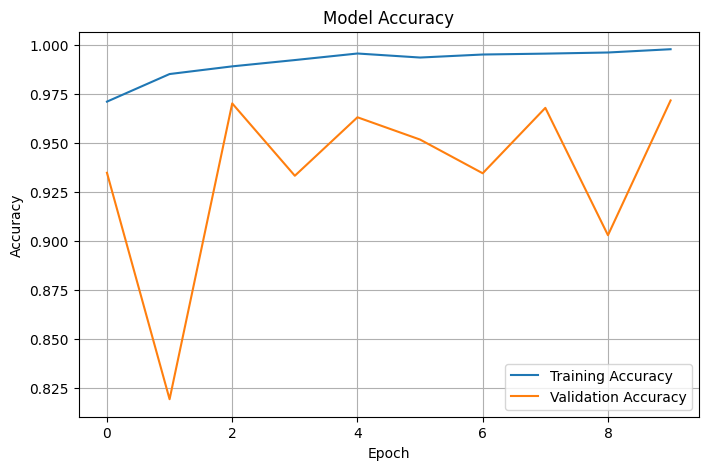

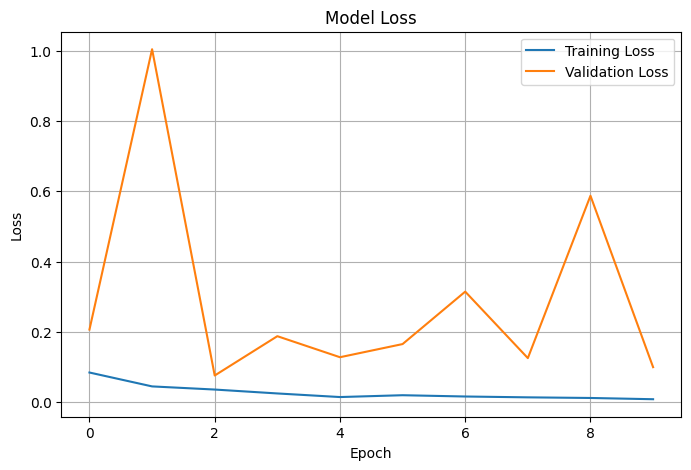

In [40]:
import matplotlib.pyplot as plt

# Accuracy

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

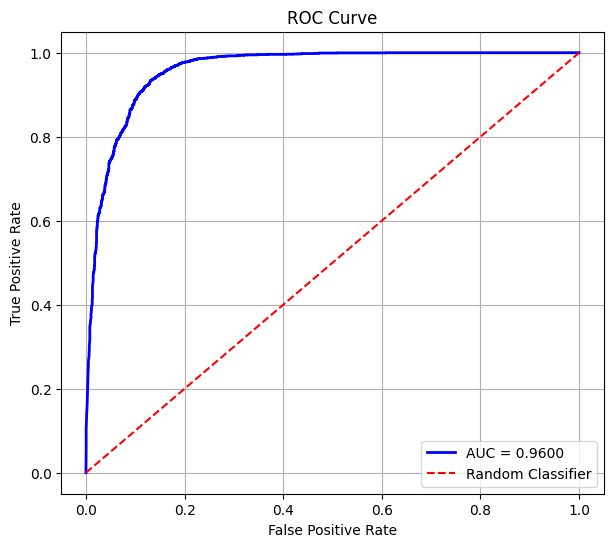

AUC Score: 0.9599607761064011


In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
y_prob = predictions.ravel()

# ROC metrics
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr,
         color='blue',
         linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1],
         color='red',
         linestyle='--',
         label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("AUC Score:", roc_auc)

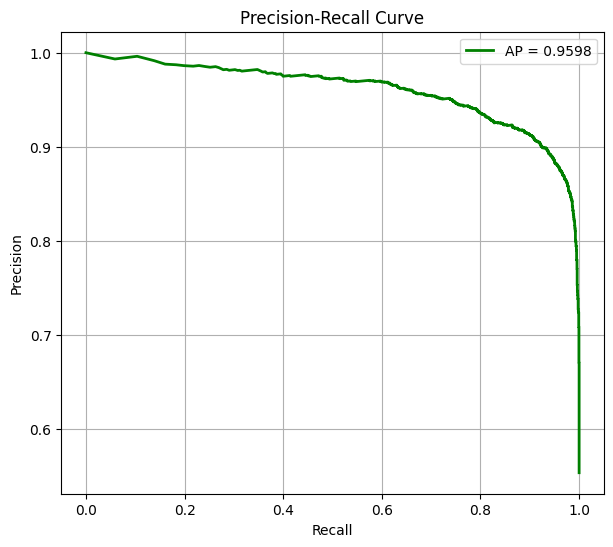

Average Precision: 0.9597853160603911


In [44]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_prob
)

ap_score = average_precision_score(y_true, y_prob)

# Plot
plt.figure(figsize=(7,6))

plt.plot(recall,
         precision,
         color='green',
         linewidth=2,
         label=f'AP = {ap_score:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

print("Average Precision:", ap_score)

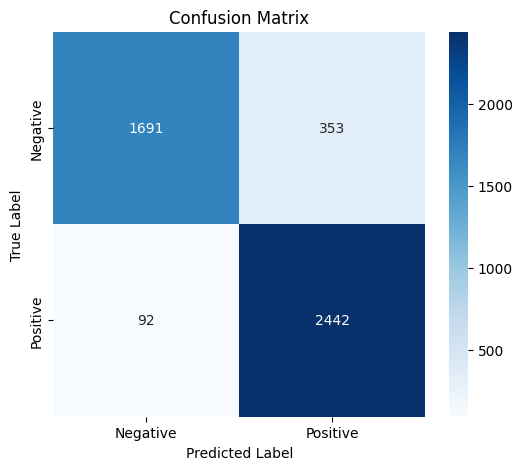

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Binary predictions
y_pred = (y_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()